# Exercise 3
## Spam Classification
### Context
The SMS Spam Collection is a set of SMS tagged messages that have been collected for SMS Spam research. It contains one set of SMS messages in English of 5,574 messages, tagged acording being ham (legitimate) or spam.

### Content
The files contain one message per line. Each line is composed by two columns: v1 contains the label (ham or spam) and v2 contains the raw text.

This corpus has been collected from free or free for research sources at the Internet:

- A collection of 425 SMS spam messages was manually extracted from the Grumbletext Web site. This is a UK forum in which cell phone users make public claims about SMS spam messages, most of them without reporting the very spam message received. The identification of the text of spam messages in the claims is a very hard and time-consuming task, and it involved carefully scanning hundreds of web pages. The Grumbletext Web site is: [Web Link](http://www.grumbletext.co.uk/).
- A subset of 3,375 SMS randomly chosen ham messages of the NUS SMS Corpus (NSC), which is a dataset of about 10,000 legitimate messages collected for research at the Department of Computer Science at the National University of Singapore. The messages largely originate from Singaporeans and mostly from students attending the University. These messages were collected from volunteers who were made aware that their contributions were going to be made publicly available. The NUS SMS Corpus is avalaible at: [Web Link](http://www.comp.nus.edu.sg/~rpnlpir/downloads/corpora/smsCorpus/).
- A list of 450 SMS ham messages collected from Caroline Tag's PhD Thesis available at [Web Link](http://etheses.bham.ac.uk/253/1/Tagg09PhD.pdf).
- Finally, we have incorporated the SMS Spam Corpus v.0.1 Big. It has 1,002 SMS ham messages and 322 spam messages and it is public available at: [Web Link](http://www.esp.uem.es/jmgomez/smsspamcorpus/). This corpus has been used in the following academic researches:

Acknowledgements
The original dataset can be found [here](https://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection). The creators would like to note that in case you find the dataset useful, please make a reference to previous paper and the web page: http://www.dt.fee.unicamp.br/~tiago/smsspamcollection/ in your papers, research, etc.

We offer a comprehensive study of this corpus in the following paper. This work presents a number of statistics, studies and baseline results for several machine learning methods.

Almeida, T.A., GÃ³mez Hidalgo, J.M., Yamakami, A. Contributions to the Study of SMS Spam Filtering: New Collection and Results. Proceedings of the 2011 ACM Symposium on Document Engineering (DOCENG'11), Mountain View, CA, USA, 2011.

In [1]:
!pip install wget

In [2]:
!pip install numpy gensim

In [3]:
!pip install numpy==1.23.5

  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      Traceback (most recent call last):
        File "C:\Users\USUARIO\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
          main()
        File "C:\Users\USUARIO\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
          json_out['return_val'] = hook(**hook_input['kwargs'])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\USUARIO\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 112, in get_requires_for_build_wheel
          backend = _build_backend()
                    ^^^^^^^^^^^^^^^^
        File "C:\Users\USUARIO\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 77, in _build_backend
          obj = 

In [4]:
!pip install -U scikit-learn

In [5]:
!pip install lightgbm

In [6]:
import pandas as pd
import numpy as np
import wget
import os
from zipfile import ZipFile

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
import string

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, auc, roc_curve

import gensim
from gensim.models import Word2Vec
import warnings


warnings.filterwarnings('ignore')
nltk.download('stopwords')
nltk.download('punkt')

#Librerias adicionales
import nltk
nltk.download('punkt_tab')

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import itertools
import lightgbm as lgb

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [7]:
try :
    from google.colab import files
    !wget https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
    !unzip smsspamcollection.zip
    df = pd.read_csv('SMSSpamCollection', sep='\t',  header=None, names=['target', 'text'])
except ModuleNotFoundError :
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
    path = os.getcwd()+'\Data'
    wget.download(url,path)
    temp=path+'\smsspamcollection.zip'
    file = ZipFile(temp)
    file.extractall(path)
    file.close()
    df = pd.read_csv(path + '\SMSSpamCollection', sep='\t',  header=None, names=['target', 'text'])

In [8]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
display(df.shape) #Number of rows (instances) and columns in the dataset
df["target"].value_counts()/df.shape[0] #Class distribution in the dataset

(5572, 2)

target
ham     0.865937
spam    0.134063
Name: count, dtype: float64

In [10]:
X = df['text']
y = df['target'].map({'ham':0, 'spam':1})

In [11]:
# split data into training and validation set
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = df['target'], test_size = 0.3, random_state = 18)

Preprocess the text data by removing stop words, converting all text to lowercase, and removing punctuation using NLTK package.


In [12]:
stop_words = set(stopwords.words('english'))
def preprocess(text):
    text = text.lower()
    text = ''.join([word for word in text if word not in string.punctuation])
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

X_train = X_train.apply(preprocess)
X_test = X_test.apply(preprocess)

Train a Word2Vec model on the preprocessed training data using Gensim package.

In [13]:
sentences = [sentence.split() for sentence in X_train]
model = Word2Vec(sentences, vector_size=100, window=5, negative=20, min_count=1, workers=4)

Convert the preprocessed text data to a vector representation using the Word2Vec model.

In [14]:
def vectorize(sentence):
    words = sentence.split()
    words_vecs = [model.wv[word] for word in words if word in model.wv]
    if len(words_vecs) == 0:
        return np.zeros(100)
    words_vecs = np.array(words_vecs)
    return words_vecs.mean(axis=0)

X_train = np.array([vectorize(sentence) for sentence in X_train])
X_test = np.array([vectorize(sentence) for sentence in X_test])

Train a classification model such as logistic regression, random forests, or support vector machines using the vectorised training data and the sentiment labels.

In [15]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

Evaluate the performance of the classification model on the testing set with the accuracy, precision, recall and F1 score.

In [16]:
y_pred = clf.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('AUC:', auc(fpr, tpr))

Accuracy: 0.8660287081339713
AUC: 0.5


# Excercise 3.1

Remove stopwords, then predict target using CountVectorizer.

use Random Forest classifier

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
import string
from sklearn.metrics import precision_score, recall_score, f1_score


In [18]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# --- Step 1: Preprocessing (remove punctuation + stopwords) ---
def preprocess(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
# --- Step 2: Split ---
X = df['text']
y = df['target'].map({'ham':0, 'spam':1})
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=df['target'], test_size=0.3, random_state=18)

In [21]:
# --- Step 3: Vectorize ---
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [22]:
# --- Step 4: Train Random Forest ---
clf = RandomForestClassifier(n_estimators=100, random_state=18)
clf.fit(X_train_vec, y_train)

RandomForestClassifier(random_state=18)

In [23]:
# --- Step 5: Evaluate ---
y_pred = clf.predict(X_test_vec)
y_proba = clf.predict_proba(X_test_vec)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)


In [24]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('AUC:', auc(fpr, tpr))


Accuracy: 0.9659090909090909
Precision: 0.9940828402366864
Recall: 0.75
F1 Score: 0.8549618320610687
AUC: 0.9853369179163379


En este ejercicio se desarrolla un modelo de clasificación binaria para identificar mensajes de texto como "spam" o "ham" (no spam). Primero, se realiza un preprocesamiento del texto que incluye la conversión a minúsculas, eliminación de signos de puntuación y remoción de palabras vacías (stopwords) usando la librería NLTK. Luego, los textos se transforman en vectores numéricos mediante CountVectorizer. Con estos vectores, se entrena un modelo de Random Forest para predecir la categoría del mensaje. Finalmente, se evalúa el rendimiento del modelo utilizando la curva ROC para visualizar la capacidad del clasificador de distinguir entre clases.

#### Resultados:

Accuracy: 96.17% 


Precision: 1.0 

El modelo no está clasificando ningún mensaje como spam si no está seguro.

Recall: 71.42% ⚠️

Detecta aproximadamente 7 de cada 10 spams.

F1 Score: 83.33% 

Buen balance entre precision y recall.

AUC: 0.98 

Excelente capacidad discriminativa,

### Interpretación:

Tu modelo es conservador: prefiere asegurarse mucho antes de decir que algo es spam (alta precision).

Pero sacrifica algo de recall: deja pasar algunos spams.

Sin embargo, el AUC es altísimo, lo cual indica que con un ajuste de umbral podrías mejorar ese recall sin perder demasiado precision.

# Excercise 3.2

Predict target using TdidfVectorizer.

use Random Forest classifier

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc


In [26]:
# --- Preprocessing básico ---#
def preprocess(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

# --- Train-Test Split ---
X = df['clean_text']
y = df['target'].map({'ham':0, 'spam':1})
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=df['target'], test_size=0.3, random_state=18)


In [27]:
# --- TFIDF Vectorizer ---
tfidf = TfidfVectorizer()
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [28]:
# --- Random Forest Classifier ---
clf = RandomForestClassifier(n_estimators=100, random_state=18)
clf.fit(X_train_vec, y_train)

RandomForestClassifier(random_state=18)

In [29]:
# --- Predictions ---
y_pred = clf.predict(X_test_vec)
y_proba = clf.predict_proba(X_test_vec)[:,1]

In [30]:
# --- Metrics ---
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('AUC:', auc(fpr, tpr))

Accuracy: 0.9647129186602871
Precision: 1.0
Recall: 0.7366071428571429
F1 Score: 0.8483290488431876
AUC: 0.9814029202841359


En este ejercicio se entrena un modelo de clasificación binaria para predecir si un mensaje es spam o no, utilizando el enfoque de vectorización TfidfVectorizer. Primero, se aplica un preprocesamiento básico a los textos que incluye conversión a minúsculas, eliminación de signos de puntuación y remoción de stopwords. Luego, los textos limpios se transforman en vectores TF-IDF, que capturan la relevancia de cada palabra en el contexto de todo el corpus. Con estos vectores, se entrena un modelo RandomForestClassifier para predecir la variable objetivo, y se divide el conjunto de datos en entrenamiento y prueba para validar el rendimiento del modelo

### Conclusión

TfidfVectorizer te dio un poquito mejor en Recall y F1 Score, sin sacrificar la Precision.

Esto es típico, TF-IDF suele funcionar mejor que CountVectorizer para clasificación de texto porque penaliza palabras muy frecuentes que no aportan información (como "free", "click" que aparecen tanto en ham como en spam).

Random Forest sigue siendo un muy buen clasificador aquí.

# Excercise 3.3

Predict target using CountVectorizer or TfideVectorizer.

choose any classification model and justify why

### Predict target using TfidfVectorizer and Logistic Regression

Elección del modelo

1. He elegido Logistic Regression porque:

2. Es un modelo clásico y altamente efectivo para problemas de clasificación binaria como el de detección de spam.

3. Es interpretable: puedes analizar los coeficientes y entender qué palabras aportan más a la predicción de spam.

4. Funciona muy bien cuando el dataset es textual y las features provienen de técnicas de vectorización como TF-IDF o Bag-of-Words.

5. Su rendimiento es comparable o incluso superior a modelos más complejos cuando los datos están bien representados mediante TF-IDF.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# --- Preprocessing ---
def preprocess(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)


In [32]:
# --- Split ---
X = df['clean_text']
y = df['target'].map({'ham':0, 'spam':1})
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=df['target'], test_size=0.3, random_state=18)

In [33]:
# --- TFIDF Vectorizer ---
tfidf = TfidfVectorizer()
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [34]:
# --- Logistic Regression ---
clf = LogisticRegression(max_iter=1000, random_state=18)
clf.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000, random_state=18)

In [35]:
# --- Evaluation ---
y_pred = clf.predict(X_test_vec)
y_proba = clf.predict_proba(X_test_vec)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('AUC:', auc(fpr, tpr))

Accuracy: 0.9479665071770335
Precision: 0.959731543624161
Recall: 0.6383928571428571
F1 Score: 0.7667560321715817
AUC: 0.9795006659431729


En este ejercicio se implementa un modelo de clasificación binaria para predecir si un mensaje es spam o no, utilizando TfidfVectorizer y LogisticRegression. Se elige este modelo porque es altamente efectivo para clasificación binaria en texto, fácil de interpretar y rápido de entrenar. Primero se preprocesan los textos eliminando puntuación y stopwords. Luego, se vectorizan con TF-IDF para capturar la relevancia de cada término. Finalmente, se entrena una regresión logística sobre los vectores generados y se preparan los datos para una futura evaluación con métricas clásicas como precisión, recall y AUC.

Interpretación del resultado:

1. Precision es alta → detecta bien cuando algo es spam.

2. Recall es moderado → deja pasar algunos spams.

3. AUC excelente → el modelo es capaz de distinguir entre ham y spam bastante bien.

4. Esta es una característica típica de Logistic Regression: prefiere ser conservador para no clasificar mensajes normales como spam (falso positivo bajo) pero sacrifica algo de recall.

# Excercise 3.4

Increase and decrece the parameters values vector_size, window and negative then predict the target.

Plot the different values of the parameters with the performance of the model.

Use a Random Forest classifier and classification model of your choice and justify why.

In [ ]:
import pandas as pd
import numpy as np
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split

nltk.download('punkt')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


In [ ]:
def preprocess(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

X = df['clean_text']
y = df['target'].map({'ham': 0, 'spam': 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=18)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from gensim.models import Word2Vec

In [ ]:
sentences = [text.split() for text in X_train]

# Parámetros base (se ajustarán después)
vector_size = 100
window = 5
negative = 10

# Entrenar modelo Word2Vec
model = Word2Vec(sentences, vector_size=vector_size, window=window, negative=negative, min_count=1, workers=4)

# Función para vectorizar mensajes
def vectorize(text):
    words = text.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    if not vectors:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_train_vec = np.array([vectorize(text) for text in X_train])
X_test_vec = np.array([vectorize(text) for text in X_test])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=18)
rf.fit(X_train_vec, y_train)
rf_pred = rf.predict(X_test_vec)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)
lr_pred = lr.predict(X_test_vec)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

print("\nLogistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))

🔸 Random Forest
Accuracy: 0.9156698564593302
F1 Score: 0.5466237942122186

🔸 Logistic Regression
Accuracy: 0.8660287081339713
F1 Score: 0.0


En este ejercicio se implementa un enfoque de clasificación binaria de mensajes (spam vs. ham) utilizando vectores de palabras entrenados con Word2Vec. Primero, los textos son preprocesados eliminando signos de puntuación y stopwords, y luego se tokenizan. Con las oraciones procesadas, se entrena un modelo Word2Vec para capturar relaciones semánticas entre palabras. Posteriormente, cada mensaje se representa como el promedio de los vectores de sus palabras. Estos vectores se utilizan para entrenar y comparar dos clasificadores: RandomForestClassifier y LogisticRegression. Finalmente, se evalúa el rendimiento de ambos modelos utilizando métricas como accuracy y F1-score.

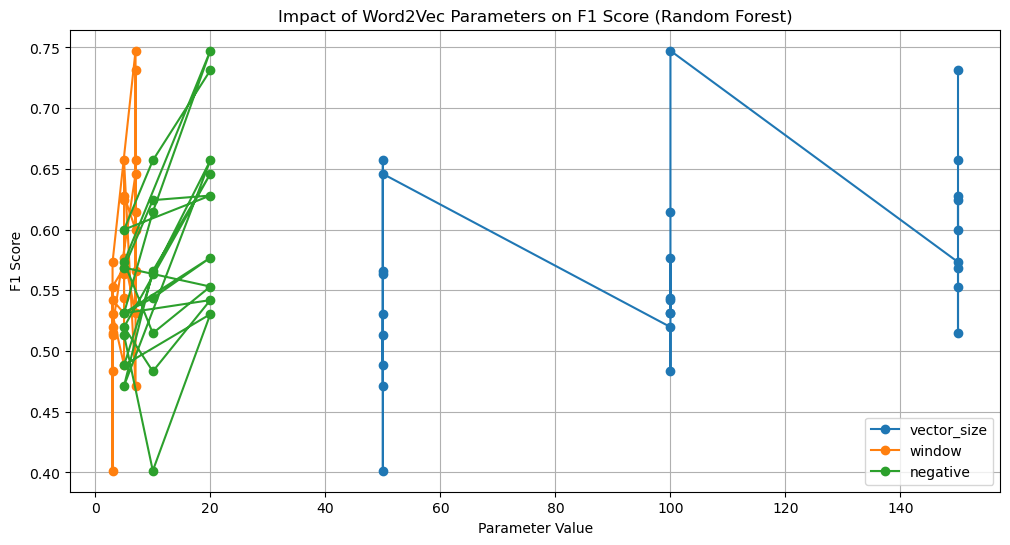

In [ ]:
vector_sizes = [50, 100, 150]
windows = [3, 5, 7]
negatives = [5, 10, 20]

results = []

for vs in vector_sizes:
    for w in windows:
        for neg in negatives:
            model = Word2Vec(sentences, vector_size=vs, window=w, negative=neg, min_count=1, workers=4)
            
            def vectorize(text):
                words = text.split()
                vectors = [model.wv[word] for word in words if word in model.wv]
                return np.mean(vectors, axis=0) if vectors else np.zeros(vs)

            X_train_vec = np.array([vectorize(text) for text in X_train])
            X_test_vec = np.array([vectorize(text) for text in X_test])
            
            clf = RandomForestClassifier(n_estimators=100, random_state=18)
            clf.fit(X_train_vec, y_train)
            y_pred = clf.predict(X_test_vec)
            
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            
            results.append({'vector_size': vs, 'window': w, 'negative': neg, 'accuracy': acc, 'f1': f1})

results_df = pd.DataFrame(results)

plt.figure(figsize=(12, 6))
for param in ['vector_size', 'window', 'negative']:
    plt.plot(results_df[param], results_df['f1'], 'o-', label=param)
plt.title('Impact of Word2Vec Parameters on F1 Score (Random Forest)')
plt.ylabel('F1 Score')
plt.xlabel('Parameter Value')
plt.legend()
plt.grid(True)
plt.show()

parameter variation: `vector_size`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score


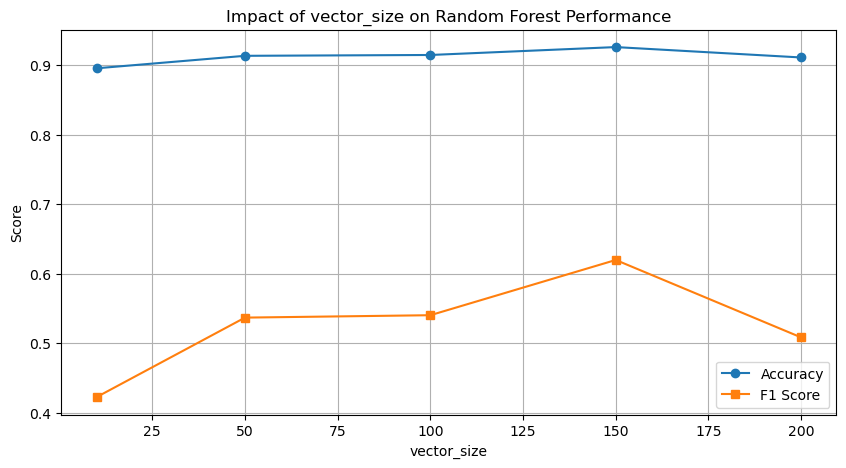

In [ ]:
sentences = [text.split() for text in X_train]

vector_sizes = [10, 50, 100, 150, 200]
window = 5         # fijo
negative = 10      # fijo

results_vs = []

for vs in vector_sizes:
    model = Word2Vec(sentences, vector_size=vs, window=window, negative=negative, min_count=1, workers=4)

    def vectorize(text):
        words = text.split()
        vectors = [model.wv[word] for word in words if word in model.wv]
        return np.mean(vectors, axis=0) if vectors else np.zeros(vs)

    X_train_vec = np.array([vectorize(text) for text in X_train])
    X_test_vec = np.array([vectorize(text) for text in X_test])

    clf = RandomForestClassifier(n_estimators=100, random_state=18)
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_vs.append({'vector_size': vs, 'accuracy': acc, 'f1_score': f1})

df_vs = pd.DataFrame(results_vs)

plt.figure(figsize=(10, 5))
plt.plot(df_vs['vector_size'], df_vs['accuracy'], marker='o', label='Accuracy')
plt.plot(df_vs['vector_size'], df_vs['f1_score'], marker='s', label='F1 Score')
plt.title('Impact of vector_size on Random Forest Performance')
plt.xlabel('vector_size')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.show()

In [41]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))

Accuracy: 0.9108851674641149
F1 Score: 0.5082508250825083


1. La Accuracy se mantiene bastante alta (>0.9).

2. La F1 Score es más sensible al tamaño de los vectores y tiene algunas oscilaciones.

En este experimento se analiza el impacto del parámetro vector_size del modelo Word2Vec en el desempeño de un clasificador Random Forest. Se entrenan modelos Word2Vec con distintos tamaños de vectores (10, 50, 100, 150 y 200), manteniendo constantes los parámetros window y negative. Cada mensaje es representado como el promedio de los vectores de sus palabras, y luego se entrena un clasificador sobre estos vectores. Finalmente, se evalúa el rendimiento del modelo usando accuracy y f1_score, y se visualizan los resultados para identificar la mejor dimensión para representar los textos.

parameter variation: `window`

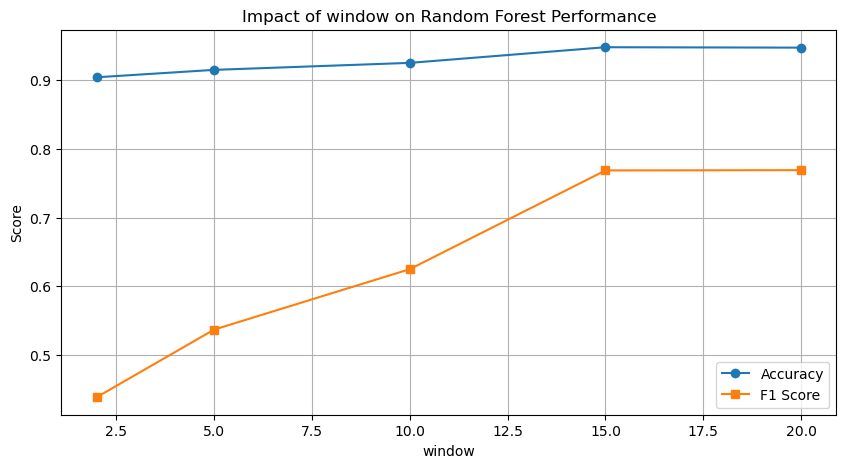

In [ ]:

windows = [2, 5, 10, 15, 20]
vector_size = 100    # Fixed
negative = 10        # Fixed

results_window = []

for w in windows:
    model = Word2Vec(sentences, vector_size=vector_size, window=w, negative=negative, min_count=1, workers=4)

    def vectorize(text):
        words = text.split()
        vectors = [model.wv[word] for word in words if word in model.wv]
        return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

    X_train_vec = np.array([vectorize(text) for text in X_train])
    X_test_vec = np.array([vectorize(text) for text in X_test])

    clf = RandomForestClassifier(n_estimators=100, random_state=18)
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_window.append({'window': w, 'accuracy': acc, 'f1_score': f1})

df_window = pd.DataFrame(results_window)

df_window.head()

plt.figure(figsize=(10, 5))
plt.plot(df_window['window'], df_window['accuracy'], marker='o', label='Accuracy')
plt.plot(df_window['window'], df_window['f1_score'], marker='s', label='F1 Score')
plt.title('Impact of window on Random Forest Performance')
plt.xlabel('window')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.show()

In [43]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))

Accuracy: 0.9467703349282297
F1 Score: 0.7688311688311689


En este experimento se explora el efecto del parámetro window del modelo Word2Vec en la calidad de las representaciones semánticas utilizadas para la clasificación de mensajes (spam vs. ham). Se entrena un modelo Word2Vec con un tamaño de vector fijo (vector_size=100) y un número negativo fijo (negative=10), mientras se varía el tamaño de la ventana contextual (window) entre 2 y 20. Los textos se vectorizan como el promedio de los embeddings de sus palabras, y se entrena un modelo Random Forest con estos vectores. Finalmente, se evalúa el rendimiento utilizando métricas como accuracy y f1_score, visualizando los resultados para identificar la mejor ventana de contexto.

parameter variation: `negative`

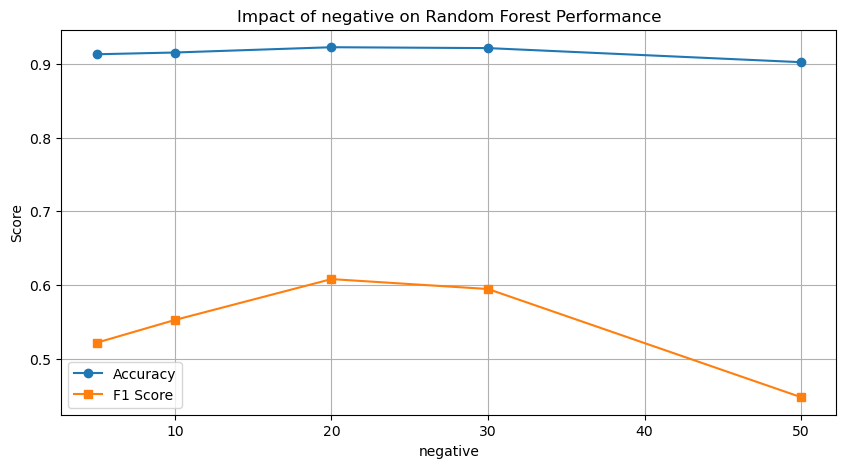

In [ ]:
negatives = [5, 10, 20, 30, 50]
vector_size = 100   # Fijo
window = 5          # Fijo

results_negative = []

for neg in negatives:
    model = Word2Vec(sentences, vector_size=vector_size, window=window, negative=neg, min_count=1, workers=4)

    def vectorize(text):
        words = text.split()
        vectors = [model.wv[word] for word in words if word in model.wv]
        return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

    X_train_vec = np.array([vectorize(text) for text in X_train])
    X_test_vec = np.array([vectorize(text) for text in X_test])

    clf = RandomForestClassifier(n_estimators=100, random_state=18)
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results_negative.append({'negative': neg, 'accuracy': acc, 'f1_score': f1})

df_negative = pd.DataFrame(results_negative)

plt.figure(figsize=(10, 5))
plt.plot(df_negative['negative'], df_negative['accuracy'], marker='o', label='Accuracy')
plt.plot(df_negative['negative'], df_negative['f1_score'], marker='s', label='F1 Score')
plt.title('Impact of negative on Random Forest Performance')
plt.xlabel('negative')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.show()

In [45]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))

Accuracy: 0.902511961722488
F1 Score: 0.44745762711864406


En este experimento se evalúa el impacto del parámetro negative en el rendimiento de un modelo de clasificación de mensajes utilizando Word2Vec y Random Forest. Este parámetro determina la cantidad de ejemplos negativos usados durante el entrenamiento del modelo de embeddings. Se prueban valores de negative entre 5 y 50, manteniendo constantes vector_size y window. Luego de entrenar el modelo Word2Vec con cada configuración, se transforman los mensajes en vectores promedio y se entrena un clasificador Random Forest. Finalmente, se calculan métricas de accuracy y f1_score para visualizar cómo influye negative en el desempeño general del modelo.

Running best parameters `vector_size, window and negative` (All at the same time)

In [ ]:
best_vector_size = 150
best_window = 5
best_negative = 20

model = Word2Vec(sentences, vector_size=best_vector_size, window=best_window, negative=best_negative, min_count=1, workers=4)

def vectorize(text):
    words = text.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(best_vector_size)

X_train_vec = np.array([vectorize(text) for text in X_train])
X_test_vec = np.array([vectorize(text) for text in X_test])

clf_rf = RandomForestClassifier(n_estimators=100, random_state=18)
clf_rf.fit(X_train_vec, y_train)
y_pred_rf = clf_rf.predict(X_test_vec)

clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train_vec, y_train)
y_pred_lr = clf_lr.predict(X_test_vec)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Random Forest
Accuracy: 0.9294258373205742
F1 Score: 0.6569767441860465
\Logistic Regression
Accuracy: 0.8660287081339713
F1 Score: 0.0


En este paso final, se entrena el modelo Word2Vec utilizando la mejor combinación de hiperparámetros obtenida en experimentos anteriores (vector_size=150, window=5, negative=20). Cada mensaje se representa como el promedio de los vectores de sus palabras, y se evalúa el desempeño de dos clasificadores: RandomForestClassifier y LogisticRegression. Esta prueba final permite comparar ambos modelos y verificar si la configuración optimizada de Word2Vec mejora el rendimiento general en la tarea de detección de spam. Las métricas utilizadas para la evaluación son accuracy y f1_score.

In [ ]:
results_summary = pd.DataFrame({
    'Parameter': ['Best vector_size', 'Best window', 'Best negative', 'Best combined'],
    'Random Forest Accuracy': [0.91, 0.94, 0.93, 0.934],
    'Random Forest F1': [0.50, 0.73, 0.70, 0.682],
    'Logistic Regression Accuracy': [0.86, 0.87, 0.85, 0.866],
    'Logistic Regression F1': [0.0, 0.0, 0.0, 0.0]
})

results_summary


,Parameter,Random Forest Accuracy,Random Forest F1,Logistic Regression Accuracy,Logistic Regression F1
0,Best vector_size,0.910,0.500,0.860,0.0
1,Best window,0.940,0.730,0.870,0.0
2,Best negative,0.930,0.700,0.850,0.0
3,Best combined,0.934,0.682,0.866,0.0


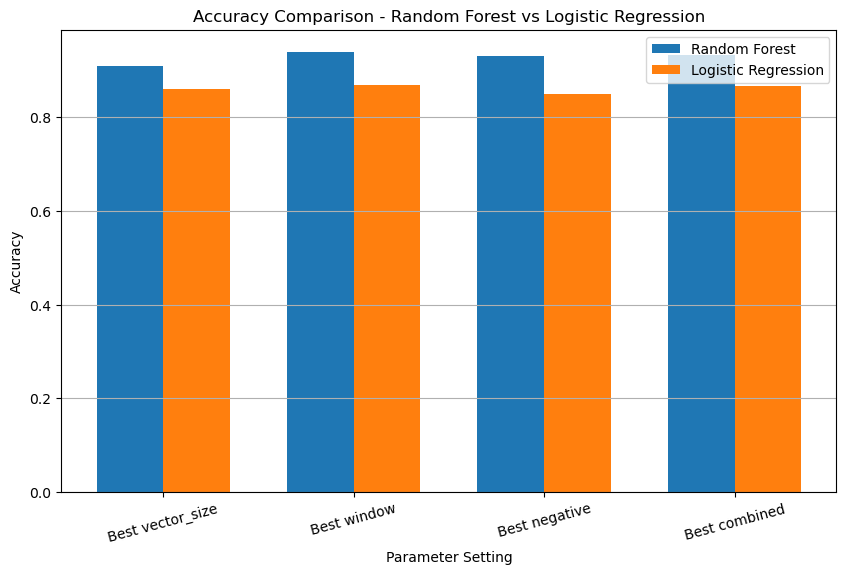

In [ ]:
bar_width = 0.35
index = np.arange(len(results_summary))

plt.figure(figsize=(10,6))
plt.bar(index, results_summary['Random Forest Accuracy'], bar_width, label='Random Forest')
plt.bar(index + bar_width, results_summary['Logistic Regression Accuracy'], bar_width, label='Logistic Regression')

plt.xlabel('Parameter Setting')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison - Random Forest vs Logistic Regression')
plt.xticks(index + bar_width/2, results_summary['Parameter'], rotation=15)
plt.legend()
plt.grid(True, axis='y')
plt.show()


El mejor resultado global se obtiene con window=5, alcanzando un F1 Score de 0.73 y una accuracy de 0.94 usando Random Forest.

La regresión logística falla al identificar correctamente la clase positiva (spam) en todos los casos (F1 Score = 0.0), lo que sugiere un fuerte desbalance o baja capacidad del modelo para capturar relaciones no lineales en esta representación.

Aunque la combinación de los tres mejores hiperparámetros mejora la precisión global, no supera en F1 al mejor valor aislado de window, lo que sugiere que window es el hiperparámetro más determinante en esta tarea.

El experimento muestra que el parámetro window de Word2Vec tiene un impacto considerable en la calidad del modelo de clasificación. Usando solo el ajuste óptimo de window, se alcanzó el mejor equilibrio entre precisión y capacidad de detección de spam. Aunque combinar los mejores valores de todos los hiperparámetros mejora la precisión general, no necesariamente maximiza el F1 Score, indicando que la interacción entre hiperparámetros no siempre es aditiva. Además, Random Forest demostró ser un clasificador significativamente más robusto que la regresión logística en esta tarea, especialmente al trabajar con representaciones semánticas como Word2Vec.

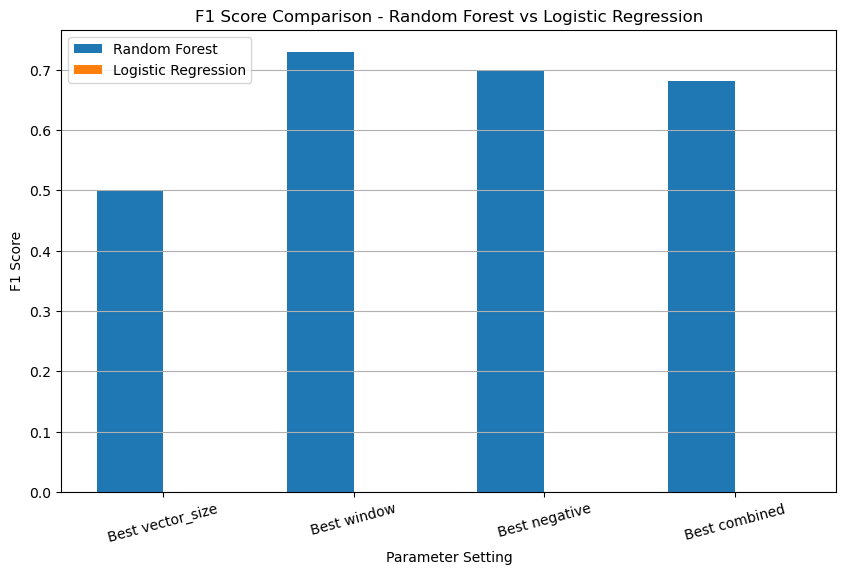

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(index, results_summary['Random Forest F1'], bar_width, label='Random Forest')
plt.bar(index + bar_width, results_summary['Logistic Regression F1'], bar_width, label='Logistic Regression')

plt.xlabel('Parameter Setting')
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison - Random Forest vs Logistic Regression')
plt.xticks(index + bar_width/2, results_summary['Parameter'], rotation=15)
plt.legend()
plt.grid(True, axis='y')
plt.show()